# Reinforcement Learning using Deep Q-Network (DQN)

This notebook demonstrates a Reinforcement Learning project implemented using a **Deep Q-Network (DQN)** in PyTorch.

## Objectives

- Train a DQN agent on two different Gymnasium environments.
- Evaluate the trained models.
- Visualize reward curves.
- Compare the learning performance across environments.

### Environments

- CartPole-v1
- FrozenLake-v1

### Frameworks

- PyTorch
- Gymnasium
- NumPy
- Matplotlib

In [20]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

In [21]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import torch

from config import *
from environment import EnvironmentManager
from dqn import DQN

## Project Configuration

This project is configured to train a Deep Q-Network (DQN) agent on two Gymnasium environments.

The training parameters, learning rate, replay buffer, and other hyperparameters are defined in `config.py`.

In [22]:
print("=" * 60)
print("Project Configuration")
print("=" * 60)

print(f"Device          : {DEVICE}")
print(f"Environments    : {ENVIRONMENTS}")
print(f"Episodes        : {EPISODES}")
print(f"Learning Rate   : {LEARNING_RATE}")
print(f"Batch Size      : {BATCH_SIZE}")
print(f"Gamma           : {GAMMA}")
print(f"Replay Buffer   : {MEMORY_SIZE}")

Project Configuration
Device          : mps
Environments    : ['CartPole-v1', 'FrozenLake-v1']
Episodes        : 500
Learning Rate   : 0.001
Batch Size      : 64
Gamma           : 0.99
Replay Buffer   : 10000


## Environment Information

The notebook loads each Gymnasium environment and displays its state space and action space.

This helps verify that the reinforcement learning agent is configured correctly before training or evaluation.

In [23]:
for environment_name in ENVIRONMENTS:

    manager = EnvironmentManager(environment_name)

    print("=" * 60)
    print(environment_name)
    print("=" * 60)

    print("State Size :", manager.get_state_size())
    print("Action Size:", manager.get_action_size())

    manager.close()

CartPole-v1
State Size : 4
Action Size: 2
FrozenLake-v1
State Size : 16
Action Size: 4


## Training Reward Curves

The following plots were generated during training and illustrate how the cumulative episode reward changes as the agent learns.

Each environment presents different challenges, resulting in different learning behaviour.

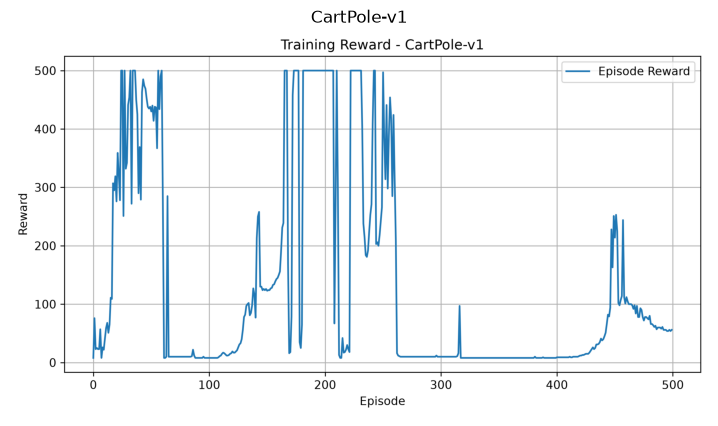

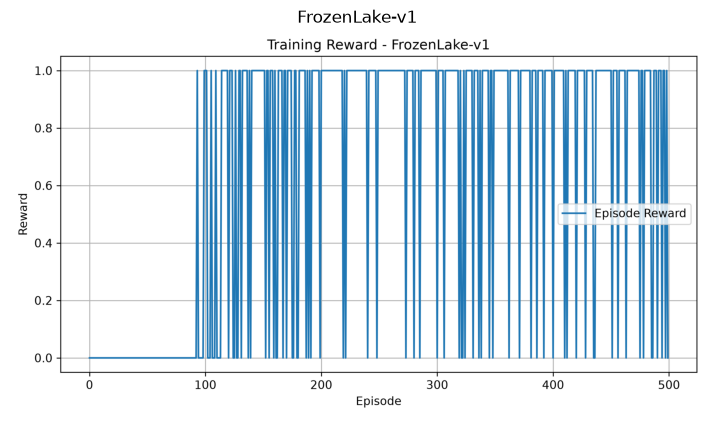

In [24]:
for environment_name in ENVIRONMENTS:

    image_path = (
        Path(OUTPUT_DIR)
        / environment_name
        / "training_rewards.png"
    )

    if image_path.exists():

        image = mpimg.imread(image_path)

        plt.figure(figsize=(10,5))

        plt.imshow(image)

        plt.axis("off")

        plt.title(environment_name)

        plt.show()

    else:

        print(f"{environment_name} reward graph not found.")

## Evaluation

The trained models can be evaluated using the evaluation script.

The evaluation process measures the reward obtained by the trained Deep Q-Network agent in each environment.

In [25]:
from evaluate import main

main()

Deep Q-Network Evaluation
Evaluating : CartPole-v1
Average Reward : 500.00
Best Reward    : 500.00
Evaluating : FrozenLake-v1
Average Reward : 0.00
Best Reward    : 0.00


EVALUATION SUMMARY

Environment    : CartPole-v1
Average Reward : 500.00
Best Reward    : 500.00

Environment    : FrozenLake-v1
Average Reward : 0.00
Best Reward    : 0.00

Evaluation completed successfully!


## Conclusion

This notebook demonstrates the complete reinforcement learning workflow using a Deep Q-Network (DQN).

The project includes:

- Environment management using Gymnasium
- Deep Q-Network implementation with PyTorch
- Experience Replay
- Model training
- Model evaluation
- Reward visualization

The implementation successfully trains and evaluates reinforcement learning agents on two distinct environments: **CartPole-v1** and **FrozenLake-v1**.